<a href="https://colab.research.google.com/github/F-Abir/GEE-Python-API/blob/main/Aridity_Index.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import ee
import geemap
import xarray as xr

In [ ]:
!pip install xee
import xee

In [ ]:
ee.Authenticate()
ee.Initialize(
    project = 'ee-a',
    opt_url = 'https://earthengine-highvolume.googleapis.com'
)

In [3]:
ee.Authenticate()
ee.Initialize(
    project = 'ee-abirnahraf',
    opt_url = 'https://earthengine-highvolume.googleapis.com'
)

In [ ]:
map = geemap.Map(basemap = 'SATELLITE')
map

In [5]:
roi = map.draw_last_feature.geometry()
roi


ee.Geometry({
  "functionInvocationValue": {
    "functionName": "Feature.geometry",
    "arguments": {
      "feature": {
        "functionInvocationValue": {
          "functionName": "Feature",
          "arguments": {
            "geometry": {
              "functionInvocationValue": {
                "functionName": "GeometryConstructors.Polygon",
                "arguments": {
                  "coordinates": {
                    "constantValue": [
                      [
                        [
                          88.076888,
                          24.221919
                        ],
                        [
                          88.076888,
                          26.445984
                        ],
                        [
                          90.003749,
                          26.445984
                        ],
                        [
                          90.003749,
                          24.221919
                        ],
                        [
                          88.076888,
                          24.221919
                        ]
                      ]
                    ]
                  },
                  "geodesic": {
                    "constantValue": false
                  }
                }
              }
            }
          }
        }
      }
    }
  }
})

In [6]:
time_start = ee.Date('2005')
time_end = ee.Date('2025')
time_dif = time_end.difference(time_start, 'year').round()
time_list = ee.List.sequence(0, ee.Number(time_dif).subtract(1)).map(
    lambda x: time_start.advance(x, 'year')
)


In [7]:
def annual(date, col):
  start_date = ee.Date(date)
  end_date = start_date.advance(1, 'year')
  img_sum = col.filterDate(start_date, end_date).sum()
  return img_sum.set('system:time_start', start_date.millis())

In [8]:
gpm = (
    ee.ImageCollection("NASA/GPM_L3/IMERG_MONTHLY_V07")
    .filterDate(time_start, time_end)
    .select('precipitation')
    .map(lambda x: x.multiply(730).copyProperties(x, ['system:time_start']))
)


In [9]:
mod = (
    ee.ImageCollection("MODIS/061/MOD16A2GF")
    .filterDate(time_start, time_end)
    .select('PET')
    .map(lambda x: x.multiply(0.1).copyProperties(x, ['system:time_start']))
)

In [10]:
gpm_annual = ee.ImageCollection(time_list.map(lambda x: annual(x, gpm)))
mod_annual = ee.ImageCollection(time_list.map(lambda x: annual(x, mod)))

In [11]:
collection = gpm_annual.combine(mod_annual)

In [12]:
ds = xr.open_dataset(
    collection,
    engine = 'ee',
    crs = 'EPSG:4326',
    scale = 0.1,
    geometry = roi
)


In [13]:
ds = ds.sortby('time') * 1

In [14]:
aridity = ds.precipitation / ds.PET

In [15]:
import matplotlib.pyplot as plt

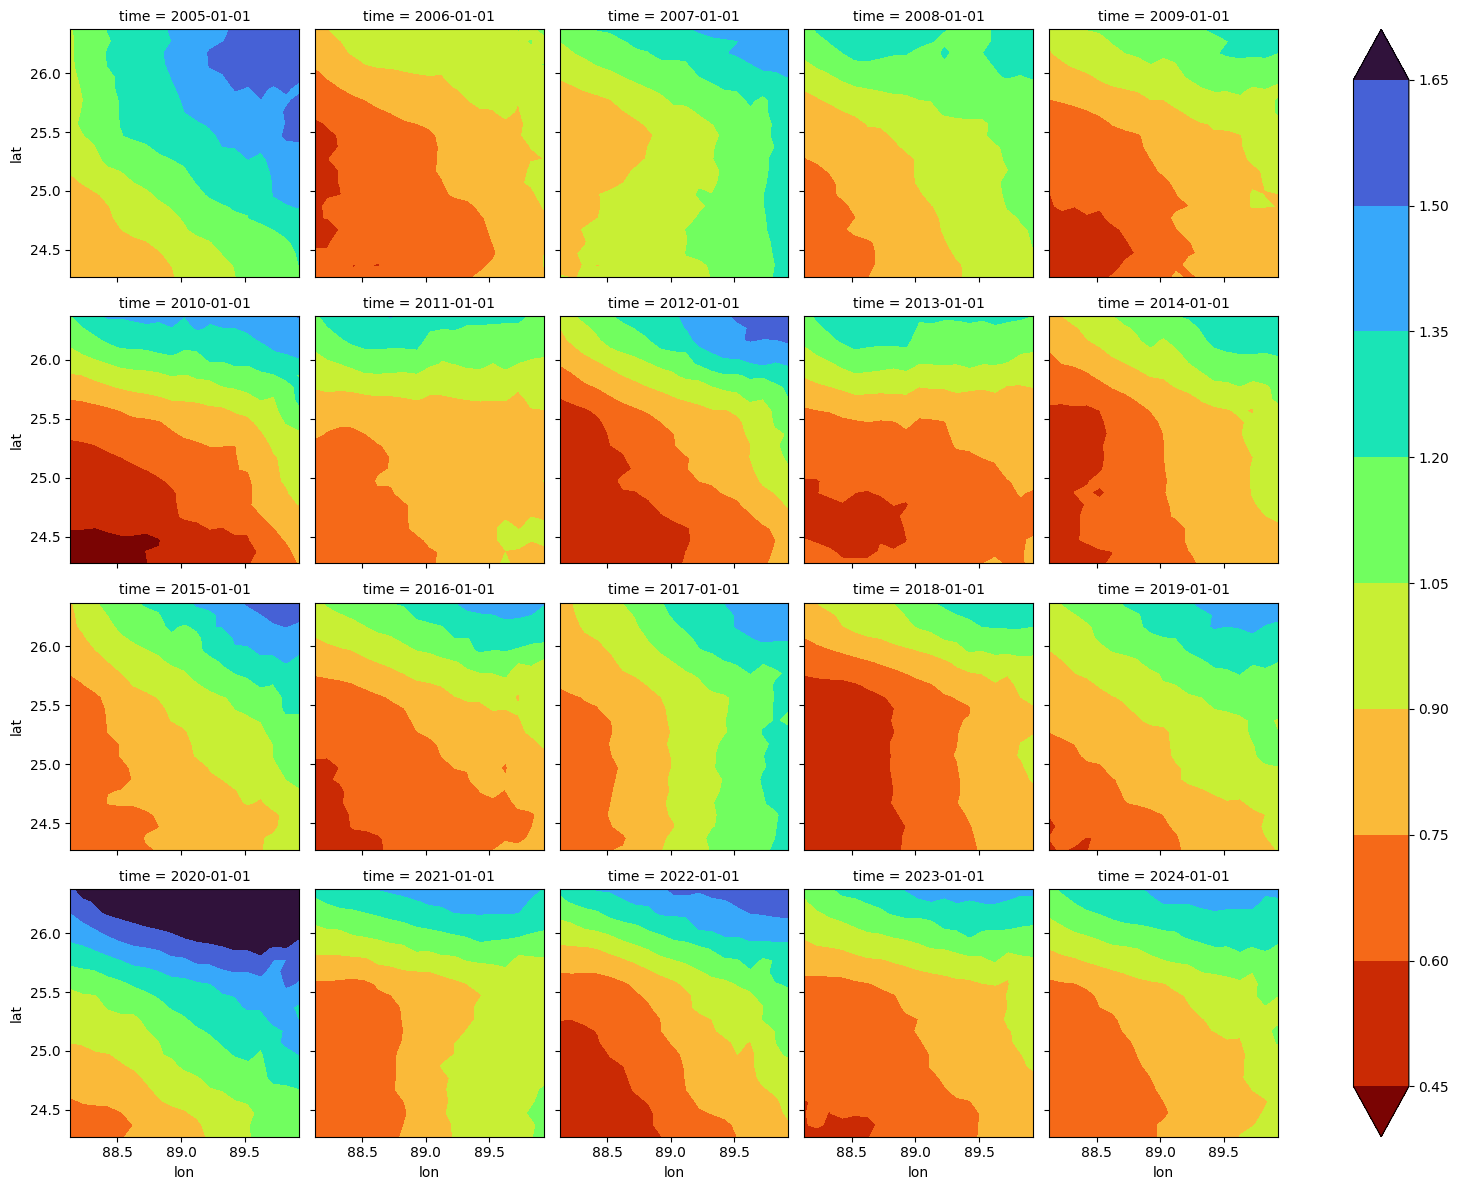

In [19]:
aridity.plot.contourf(
    x = 'lon',
    y = 'lat',
    col = 'time',
    col_wrap = 5,
    robust = True,
    levels = 10,
    cmap = 'turbo_r'

)
plt.show()

In [22]:
import numpy as np


In [23]:
aridity_map = xr.where(aridity < 0.05, 1,
                       xr.where(
                           aridity < 0.2, 2,
                           xr.where(
                               aridity < 0.5, 3,
                               xr.where(
                                   aridity < 1, 4, np.nan
                               )
                           )
                       ))


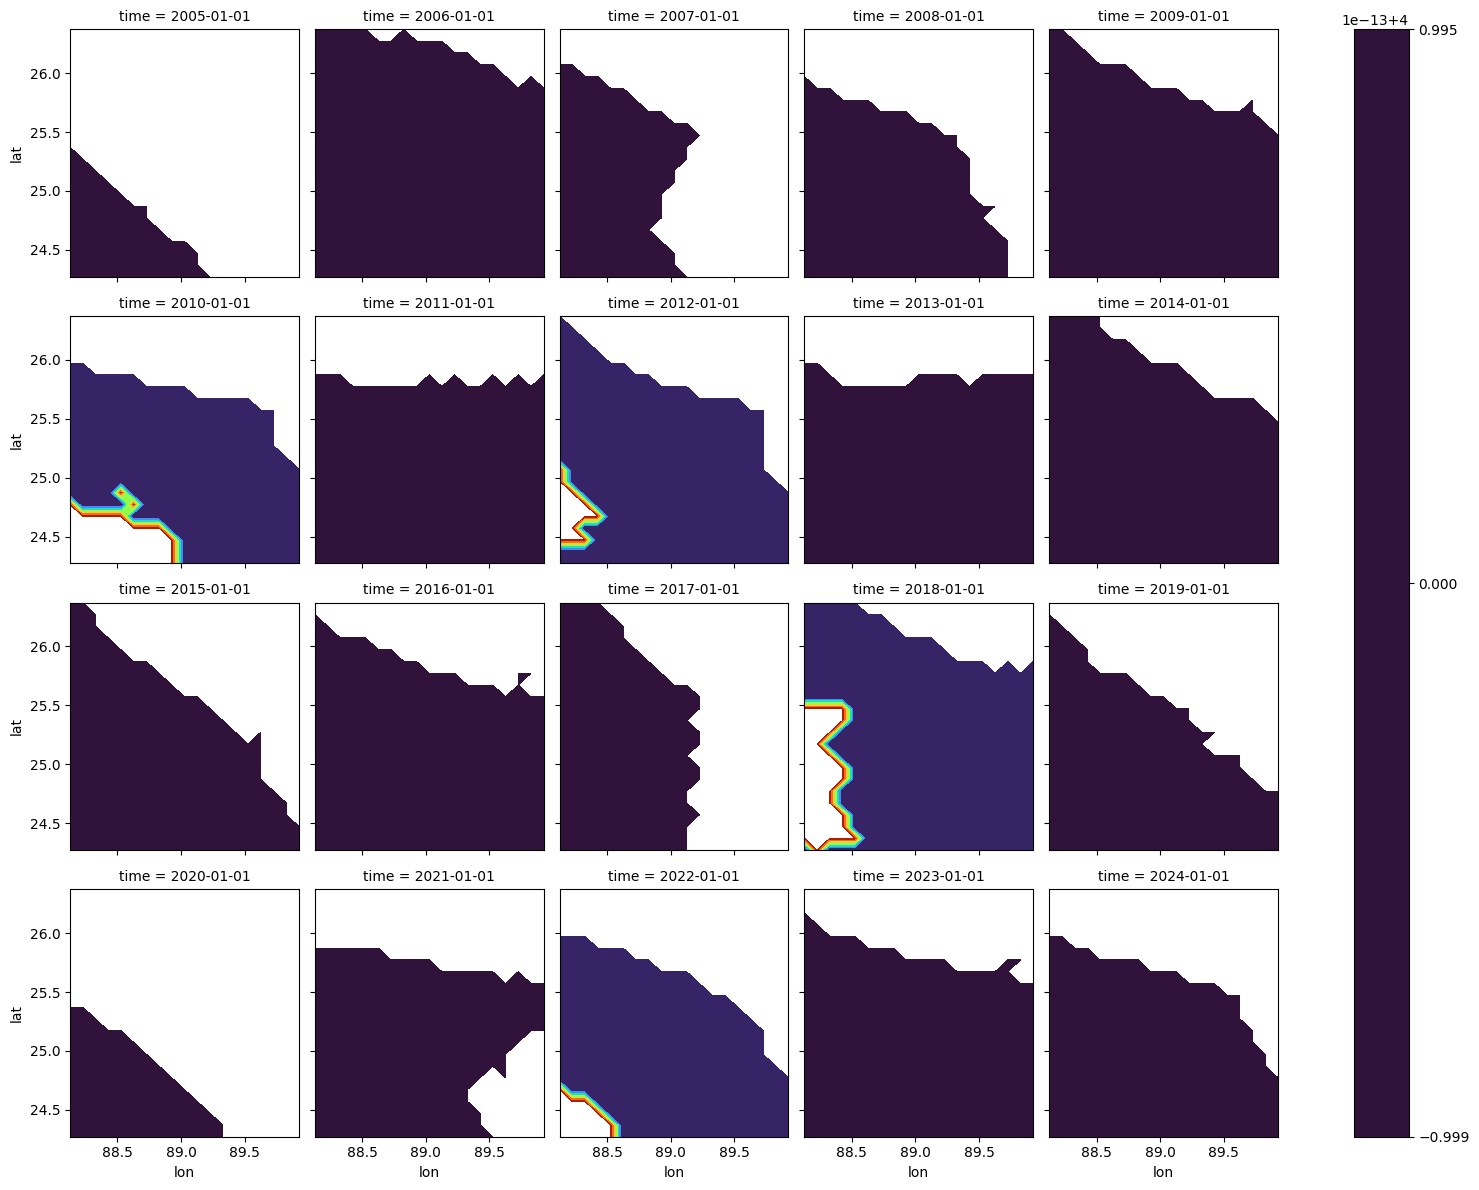

In [24]:
aridity_map.plot.contourf(
    x = 'lon',
    y = 'lat',
    col = 'time',
    col_wrap = 5,
    cmap = 'turbo_r'
)